# 04. Topological Data Analysis

## 0. TDA Environment and Literature

## 1. TDA Environment and Literature

This notebook develops the Topological Data Analysis (TDA) component of the
project.

The methodology is motivated in part by the approach of Gidea and Katz [1],
who applied persistent homology and persistence landscapes to financial
time series using sliding-window point clouds.

Our analysis is not intended to reproduce their study exactly. Instead, we
adapt the general idea of extracting topological information from financial
time-series dynamics to a single publicly available asset, SPY, and examine
whether such information can contribute to the volatility-prediction problem
studied in this project.

We begin with a simple delay-coordinate embedding and progressively examine
more appropriate representations and time-local topological features.

We start with two core packages:

- `ripser`, for computing persistent homology.
- `persim`, for visualizing and analyzing persistence diagrams.

Additional packages will be introduced only when they are needed for a
specific analysis.

In [ ]:
# Install the core TDA packages
#-- uncomment the code below to install risper and persim --#
#%pip install ripser persim

## 1. Imports and Project Path
We import the numerical and plotting tools used throughout the notebook,
together with the TDA-specific functionality.

The `StandardScaler` will be used later when appropriate to put coordinates
of a point cloud on comparable scales. Standardization centers each feature
and scales it to unit variance. :contentReference[oaicite:2]{index=2}

### 1.1: Define Project Path

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
CLEAN_DATA_FILE = PROCESSED_DATA_DIR / "spy_daily_clean.csv"

### 1.2: Import Libraries

In [2]:
# General scientific computing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TDA

from ripser import ripser
from persim import plot_diagrams

# Scaling

from sklearn.preprocessing import StandardScaler

# Project modules
from src.tda import (
    delay_embedding,
    sliding_windows,
    sliding_window_dates,
    persistence_statistics,
    compute_persistence_diagram, 
)

In [3]:
# Verify the TDA packages

import ripser as ripser_module
import persim

from ripser import ripser
from persim import plot_diagrams

print(f"ripser version: {ripser_module.__version__}")
print(f"persim version: {persim.__version__}")

ripser version: 0.6.15
persim version: 0.3.8


## 2. Load the Market Data

The topological analysis is based on the same cleaned SPY dataset used in
the conventional exploratory analysis.

We will not apply persistent homology directly to the raw price series.
Instead, we will construct a geometric representation of the temporal
dynamics of the market.

This distinction is important: persistent homology is applied to a
collection of points equipped with a notion of distance. Therefore, the
first task is to determine how a one-dimensional financial time series can
be represented as a point cloud.

In [4]:
# Load the cleaned SPY data

spy_data = pd.read_csv(
    CLEAN_DATA_FILE,
    index_col=0,
    parse_dates=True
)

spy_data.head()

,Close,High,Low,Open,Volume
2010-01-04,84.578491,84.623268,83.220220,83.862041,118944600
2010-01-05,84.802376,84.839693,84.220261,84.526247,111579900
2010-01-06,84.862091,85.071055,84.653127,84.720292,116074400
2010-01-07,85.220306,85.324788,84.466539,84.705356,131091100
2010-01-08,85.503906,85.541224,84.824774,84.996420,126402800


Now, construct the daily return:

In [5]:
# Calculate daily log returns

spy_data["log_return"] = np.log(
    spy_data["Close"] / spy_data["Close"].shift(1)
)

spy_data["log_return"].describe()

count    4190.000000
mean        0.000525
std         0.010777
min        -0.115887
25%        -0.003711
50%         0.000704
75%         0.005774
max         0.099863
Name: log_return, dtype: float64

## 3. From a Time Series to a Geometric Object

A financial return series is a one-dimensional sequence,

$$
r_1,r_2,\ldots,r_N.
$$

Persistent homology, however, studies the topology of geometric objects.
We therefore need to construct a point cloud from the temporal evolution of
the return series.

A natural approach is to use a delay-coordinate embedding.

For a delay $(\tau)$ and embedding dimension $(d)$, define

$$
x_t =
\left(
r_t,
r_{t-\tau},
r_{t-2\tau},
\ldots,
r_{t-(d-1)\tau}
\right).
$$

Each time \(t\) is therefore represented by a point

$$
x_t\in\mathbb{R}^d.
$$

The collection

$$
\mathcal{X}
=
\{x_t\}
$$

forms a point cloud representing the temporal geometry of the return
dynamics.

We will study the topology of this point cloud rather than the topology of
the raw price curve.

### Why this representation?
Two observations that have similar recent histories will lie close to one
another in the reconstructed state space. Conversely, observations with
different local temporal patterns may be separated.

This allows us to ask whether the return dynamics exhibit geometric
structures—such as clusters, loops, or other persistent features—that are
not apparent from conventional summary statistics.

### 3.1: A Two-Dimensional Delay Embedding

We begin with the simplest non-trivial delay embedding,

$$
x_t=(r_t,r_{t-\tau}).
$$

For the initial visualization we choose a delay of one trading day:

$$
\tau=1.
$$

Thus each point records the return today together with the return on the
previous trading day.

This is not our final TDA representation, but a deliberately chosen simple
starting point that allows us to inspect what the reconstructed state space
looks like before making higher-dimensional choices.

In [6]:
# Construct a two-dimensional delay embedding

TAU = 1

returns = spy_data["log_return"].dropna()

embedding_2d = np.column_stack(
    [
        returns.iloc[TAU:].to_numpy(),
        returns.iloc[:-TAU].to_numpy()
    ]
)

embedding_2d.shape

(4189, 2)

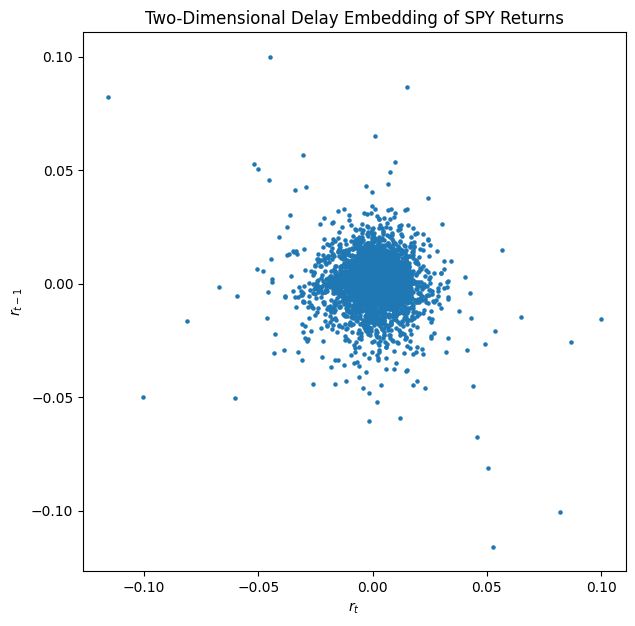

In [7]:
# Visualize the two-dimensional delay embedding

plt.figure(figsize=(7, 7))

plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    s=5
)

plt.xlabel(r"$r_t$")
plt.ylabel(r"$r_{t-1}$")
plt.title("Two-Dimensional Delay Embedding of SPY Returns")

plt.show()

**Observation:** 
A few observations are worth recording, but we should not interpret the topology yet:

- The cloud is roughly concentrated around \((0,0)\), which is consistent with most daily returns being   relatively small.
- There are substantial tails/outliers corresponding to unusually large return movements.
- The cloud does not visually exhibit an obvious loop or circular structure.
- That last point is important: we should not expect persistent \(H_1\) structure simply because we're doing   TDA. Whether meaningful \(H_1\) features exist is precisely something persistence analysis should test.

There is also an important methodological point here. With $\tau=1$,

$$ x_t=(r_t,r_{t-1}), $$

so we're asking whether the one-day temporal relationship between consecutive returns produces a nontrivial geometric structure.

### 3.2: From Delay Embeddings to Sliding Windows

The two-dimensional delay embedding above provides a simple global
representation of the temporal dependence between consecutive returns.

However, financial markets are nonstationary: their statistical and
geometric properties can change substantially over time. A single point cloud
constructed from the entire dataset may therefore obscure important local
structure.

To obtain a time-dependent representation, we follow the general strategy
of Gidea and Katz [1] and introduce a sliding-window construction.

For a window of length \(W\), define

$$
X_t =
\{x_t,x_{t+1},\ldots,x_{t+W-1}\}.
$$

As the window moves through time, we obtain a sequence of point clouds

$$
X_1,X_2,\ldots,X_T.
$$

Persistent homology can then be computed separately for each \(X_t\),
producing a sequence of persistence diagrams.

This allows us to study how the topology of the reconstructed market state
changes through time and, in particular, whether topological quantities
change during periods of elevated market volatility.

Our implementation is inspired by Gidea and Katz [1], but differs from their
study in several respects. They analyze multiple financial indices
simultaneously, whereas we focus on SPY. We also use a more recent sample
containing several distinct market regimes and investigate the relationship
between topological features and future five-day realized volatility.

The goal is therefore not to assume that topology identifies crashes, but to
test whether time-local topological structure contains information about
subsequent volatility.

In [8]:
# Let's start with a 20 trading-days window
WINDOW_SIZE = 20

window_returns = returns.iloc[:WINDOW_SIZE].to_numpy()

window_returns.shape

(20,)

this is still one-dimensional, whereas Gidea–Katz construct point clouds from multidimensional observations. For our single-series SPY data, we can turn each window into a point cloud using the delay embedding.

For a delay \(\tau=1\),

$$ (r_t,r_{t-1}) $$

gives us 19 points from a 20-day window.

In [9]:
TAU = 1

window_embedding = np.column_stack(
    [
        window_returns[TAU:],
        window_returns[:-TAU]
    ]
)

window_embedding.shape

(19, 2)

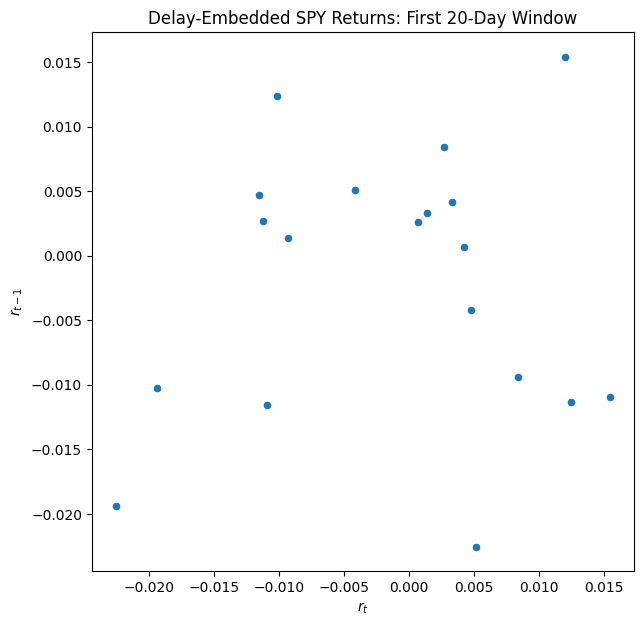

In [10]:
# visualize it
plt.figure(figsize=(7, 7))

plt.scatter(
    window_embedding[:, 0],
    window_embedding[:, 1],
    s=20
)

plt.xlabel(r"$r_t$")
plt.ylabel(r"$r_{t-1}$")
plt.title("Delay-Embedded SPY Returns: First 20-Day Window")

plt.show()

**Why this is the right next step:**

Now we have explicitly constructed

$$ X_1 = \left\{ (r_2,r_1), (r_3,r_2), \ldots, (r_{20},r_{19}) \right\}. $$

Then the next window is

$$ X_2 = \left\{ (r_3,r_2), (r_4,r_3), \ldots, (r_{21},r_{20}) \right\}, $$

and so on.

So eventually we want

$$ X_1,X_2,\ldots,X_T, $$

where each \(X_t\) is a point cloud.

This is the key transition toward the Gidea–Katz methodology: the topology becomes time-dependent. Their paper explicitly constructs time-dependent point clouds using a sliding window and then tracks persistent topological features and persistence landscapes through time.

## 4. Simple Baseline Persistent Homology

The two-dimensional delay embedding gives us a point cloud

$$
\mathcal{X}=\{x_1,\ldots,x_N\}\subset\mathbb{R}^2.
$$

We now study the topology of this point cloud using persistent homology.

Rather than choosing a single distance scale, persistent homology examines
the geometry across a continuously varying scale parameter.

For each scale $\epsilon$, we construct a simplicial complex from the
point cloud. As $\epsilon$ increases, connected components may merge and
higher-dimensional structures may appear and disappear.

Persistent homology records these changes in the form of persistence
diagrams.

For this initial analysis we compute

$$
H_0 \quad\text{and}\quad H_1.
$$

Here:

- $H_0$ describes connected components of the point cloud.
- $H_1$ describes one-dimensional topological features, such as loops.

A feature that persists over a substantial range of scales is generally
more significant than a feature that exists only briefly.

In [11]:
# Compute persistent homology of the delay embedding

tda_result = ripser(
    embedding_2d,
    maxdim=1
)

diagrams = tda_result["dgms"]

print("H0 diagram shape:", diagrams[0].shape)
print("H1 diagram shape:", diagrams[1].shape)

H0 diagram shape: (4189, 2)
H1 diagram shape: (1102, 2)


*What these arrays mean?*

Well, each row of a persistence diagram is of the form

$$ (b,d), $$

where \(b\) is the birth scale and \(d\) is the death scale of a topological feature. The `diagram[0]` contains 4189 $H_0$ persistent pairs, while `diagram[1]` contains 1102 $H_1$.

For $H_0$, this makes intuitive sense. Initially, when the distance scale is essentially zero, each of our 4189 points is its own connected component. As we increase the distance scale, these components merge. Eventually only one component remains.

For $H_1$, the situation is different. The 1102 entries represent candidate one-dimensional cycles across different scales. Most of them may be very short-lived. We need to distinguish persistent features from these small, likely noise-sensitive features.

### 4.1: Persistence Diagrams

The persistence pairs can be visualized in a persistence diagram.

For a feature born at scale \(b\) and dying at scale \(d\), we plot the point

$$
(b,d).
$$

The persistence of the feature is

$$
d-b.
$$

Features close to the diagonal \(b=d\) have short lifetimes, whereas features
far from the diagonal persist across a larger range of scales.

We therefore use the distance from the diagonal as a first indication of the
relative persistence of a topological feature.

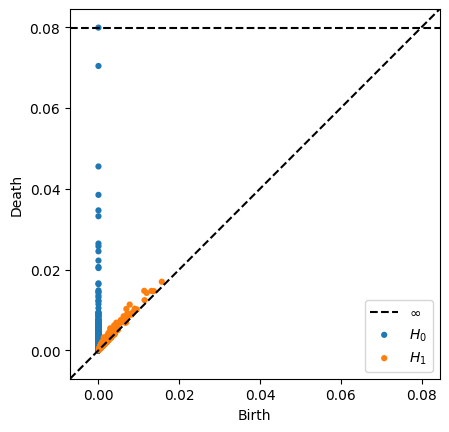

In [12]:
plot_diagrams(
    diagrams,
    show=True
)

## 5. Sliding Window TDA

### 5.1: Constructing a Sliding-Window

The baseline analysis in Section 4 constructs one point cloud from the entire
sample. This provides a useful first experiment, but it does not preserve the
time-local nature of financial dynamics.

Financial markets are nonstationary: the statistical properties of returns
can change substantially over time. A representation that combines the entire
2010--present sample may therefore obscure local geometric structure.

To address this, we now introduce a sliding-window construction inspired by
Gidea and Katz [1].

At each time \(t\), we consider a window of observations surrounding that
time. We then construct a point cloud from the observations in that window
and compute its topological properties.

Moving the window through time produces a sequence of point clouds,

$$
X_1,X_2,\ldots,X_T.
$$

Consequently, persistent homology will no longer give us one persistence
diagram for the entire dataset. Instead, it will give us a sequence

$$
D_1,D_2,\ldots,D_T,
$$

allowing us to study how the topology of the market evolves through time.

Our implementation adapts the Gidea--Katz idea to a single asset, SPY. Their
analysis uses several financial indices simultaneously, whereas our point
clouds will be constructed from the temporal dynamics of SPY returns.

We begin with a single window before constructing the complete sequence.

In [13]:
# choose the window parameters
WINDOW_SIZE = 20
STEP = 1

In [14]:
# construct all sliding windows
windows = sliding_windows(
    returns.to_numpy(),
    window_size=WINDOW_SIZE,
    step=STEP
)

print("Number of windows:", len(windows))
print("Length of first window:", len(windows[0]))
print("Length of second window:", len(windows[1]))

Number of windows: 4171
Length of first window: 20
Length of second window: 20


In [15]:
# construct the first local point cloud 
TAU = 1
DIMENSION = 2

first_window = windows[0]

first_embedding = delay_embedding(
    first_window,
    tau=TAU,
    dimension=DIMENSION
)

print("Window shape:", first_window.shape)
print("Point-cloud shape:", first_embedding.shape)

Window shape: (20,)
Point-cloud shape: (19, 2)


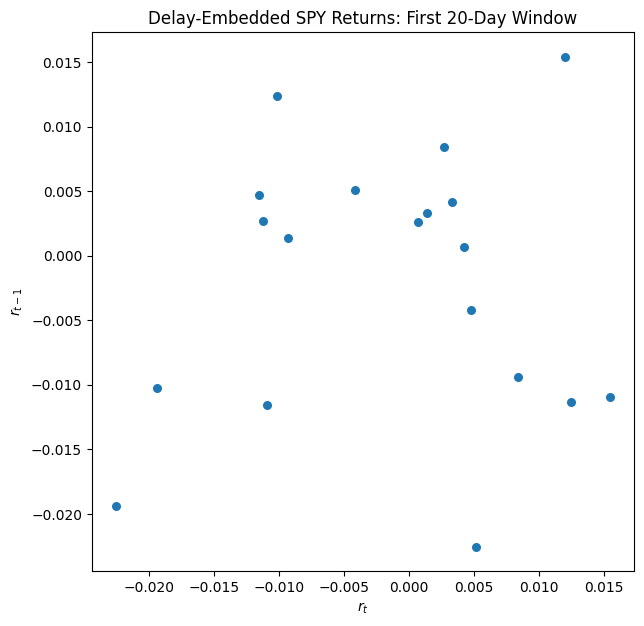

In [16]:
# visalize the first local point cloud 
plt.figure(figsize=(7, 7))

plt.scatter(
    first_embedding[:, 0],
    first_embedding[:, 1],
    s=30
)

plt.xlabel(r"$r_t$")
plt.ylabel(r"$r_{t-1}$")
plt.title("Delay-Embedded SPY Returns: First 20-Day Window")

plt.show()

In [17]:
window_dates = sliding_window_dates(
    returns.index,
    window_size=WINDOW_SIZE,
    step=STEP
)

print("Number of windows:", len(windows))
print("Number of window dates:", len(window_dates))
print("First window ends:", window_dates[0])
print("Second window ends:", window_dates[1])
print("Last window ends:", window_dates[-1])

Number of windows: 4171
Number of window dates: 4171
First window ends: 2010-02-02 00:00:00
Second window ends: 2010-02-03 00:00:00
Last window ends: 2026-09-01 00:00:00


This confirms an important point: because returns begins one trading day after the price series begins, the first 20-return window ends on 2010-02-02, which is correct.

So Section 5.1 is now complete. We have:

$$ W_t \longrightarrow X_t \longrightarrow t, $$

where each local window $W_t$ has a corresponding date and is transformed into a delay-embedded point cloud $X_t$.

### 5.2 Persistent Homology for Each Window

For each sliding window, we now compute the persistent homology of its
delay-embedded point cloud.

For a window $W_t$, let

$$
X_t = \operatorname{DelayEmbed}(W_t;\tau,d)
$$

denote the corresponding point cloud. Applying persistent homology gives

$$
D_t = \operatorname{PH}(X_t),
$$

where $D_t$ contains the persistence intervals of the connected components
and higher-dimensional topological features.

We begin with a single window to make the construction explicit before
applying it to the complete sequence of windows.

In [18]:
# Persistent homology of the first local window

first_diagram = compute_persistence_diagram(
    first_embedding,
    max_dimension=1
)

print("H0 diagram shape:", first_diagram[0].shape)
print("H1 diagram shape:", first_diagram[1].shape)

H0 diagram shape: (19, 2)
H1 diagram shape: (0, 2)


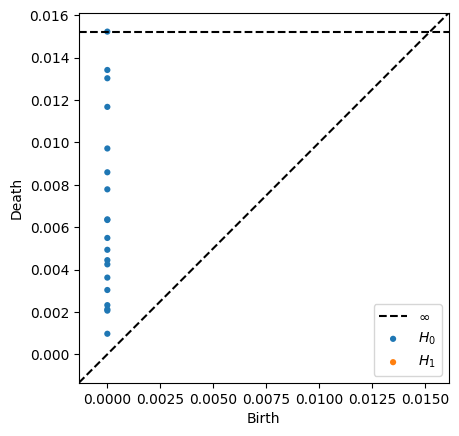

In [19]:
plot_diagrams(
    first_diagram,
    show=True
)

**Observation**

For the 19-point local cloud:

$H_0$ has 19 persistence pairs. This is expected: initially, each of the 19 points is its own connected component.
One $H_0$ component persists indefinitely. In the plot, this is the point at the top boundary, representing the essential connected component.
The remaining $H_0$ components eventually merge as the distance scale increases.
$H_1$ is empty:
$$ H_1 = \varnothing. $$

So at the scales detected by the Vietoris–Rips filtration, this particular 20-day window does not produce a persistent one-dimensional loop.

Recall, in Section 4, when we applied persistent homology to the entire 2010–present point cloud, we obtained:

H1 diagram shape: (1102, 2)

whereas this first local window gives:

H1 diagram shape: (0, 2)

This illustrates why the sliding-window construction is interesting. The global point cloud mixes many years and many market regimes together, whereas the local point cloud asks:

What geometric structure is present in the market dynamics during this particular period?

Next, let's quantify the persistence of the \(H_0\) features for this first window:

In [20]:
h0_persistence = (
    first_diagram[0][:, 1]
    - first_diagram[0][:, 0]
)

print("H0 persistence values:")
print(h0_persistence)

H0 persistence values:
[0.00096904 0.00206065 0.00212237 0.00231975 0.00303413 0.00361946
 0.00424442 0.00444261 0.00493227 0.00549079 0.00633771 0.00636917
 0.00778472 0.00859016 0.00971362 0.01167663 0.01302765 0.01341796
        inf]


then let's separate the finite features:

In [21]:
h0_stats = persistence_statistics(
    first_diagram[0]
)

h1_stats = persistence_statistics(
    first_diagram[1]
)

print("H0 statistics:")
for key, value in h0_stats.items():
    print(f"  {key}: {value}")

print("\nH1 statistics:")
for key, value in h1_stats.items():
    print(f"  {key}: {value}")

H0 statistics:
  n_features: 19
  n_finite: 18
  n_infinite: 1
  total_persistence: 0.11015311384107918
  mean_persistence: 0.00611961743561551
  max_persistence: 0.013417959213256836

H1 statistics:
  n_features: 0
  n_finite: 0
  n_infinite: 0
  total_persistence: 0.0
  mean_persistence: 0.0
  max_persistence: 0.0


#### 5.2.1: Persistent Homology Across All Windows

We now extend the calculation from a single local window to the complete
sequence of sliding windows.

For each window \(W_t\), we:

1. construct the delay-coordinate embedding \(X_t\);
2. compute its persistence diagrams \(D_t\);
3. extract summary statistics from the \(H_0\) and \(H_1\) diagrams.

This produces a time series of topological quantities associated with the
ending date of each window.

We use the current experimental parameters

$$
W=20,\qquad \tau=1,\qquad d=2.
$$

At this stage, these parameters should be regarded as a baseline choice,
rather than as an optimized configuration. Later experiments will examine
how the results depend on the window size, delay, and embedding dimension.

In [22]:
# Compute topological statistics for every sliding window

results = []

for window, date in zip(windows, window_dates):

    embedding = delay_embedding(
        window,
        tau=TAU,
        dimension=DIMENSION
    )

    diagrams = compute_persistence_diagram(
        embedding,
        max_dimension=1
    )

    h0_stats = persistence_statistics(diagrams[0])
    h1_stats = persistence_statistics(diagrams[1])

    results.append(
        {
            "date": date,
            "h0_total_persistence": h0_stats["total_persistence"],
            "h0_mean_persistence": h0_stats["mean_persistence"],
            "h0_max_persistence": h0_stats["max_persistence"],
            "h1_total_persistence": h1_stats["total_persistence"],
            "h1_mean_persistence": h1_stats["mean_persistence"],
            "h1_max_persistence": h1_stats["max_persistence"],
            "h1_n_features": h1_stats["n_features"],
        }
    )

In [23]:
tda_results = pd.DataFrame(results)

tda_results.head()

,date,h0_total_persistence,h0_mean_persistence,h0_max_persistence,h1_total_persistence,h1_mean_persistence,h1_max_persistence,h1_n_features
0,2010-02-02,0.110153,0.006120,0.013418,0.000000,0.000000,0.000000,0
1,2010-02-03,0.113985,0.006333,0.013418,0.001681,0.001681,0.001681,1
2,2010-02-04,0.126696,0.007039,0.013418,0.001681,0.001681,0.001681,1
3,2010-02-05,0.134904,0.007495,0.013418,0.001681,0.001681,0.001681,1
4,2010-02-08,0.136133,0.007563,0.013418,0.001681,0.001681,0.001681,1


In [24]:
print("Number of observations:", len(tda_results))
print("Number of columns:", len(tda_results.columns))

Number of observations: 4171
Number of columns: 8


In [25]:
print(
    "Windows with H1 features:",
    (tda_results["h1_n_features"] > 0).sum()
)

print(
    "Fraction of windows with H1 features:",
    (tda_results["h1_n_features"] > 0).mean()
)

Windows with H1 features: 3843
Fraction of windows with H1 features: 0.9213617837449053


**Observation:**

We have:

- 4,171 local windows.
- $H_1$ is nonempty in 3,843 windows.
- Fraction with $H_1$ features:

$$ \frac{3843}{4171}\approx 0.9214, $$

so about 92.1% of the windows contain at least one $H_1$ feature.

That is substantially different from the first window, where $H_1$ was empty. So the absence of $H_1$ in the first window was not representative of the whole sample.

But let's not interpret this as "92% of windows have meaningful loops"

That's too strong at this stage. A persistence diagram can contain very short-lived \(H_1\) features. What matters is not merely whether

$$ H_1\neq\varnothing, $$

but also the persistence of those features. So the next thing we want to know is how many $H_1$ features each window contains.

In [26]:
h1_feature_counts = (
    tda_results["h1_n_features"]
    .value_counts()
    .sort_index()
)

h1_feature_counts

h1_n_features
0     328
1    1195
2    1462
3     836
4     289
5      55
6       6
Name: count, dtype: int64

In [27]:
print(
    "Maximum number of H1 features in any window:",
    tda_results["h1_n_features"].max()
)

print(
    "Windows with more than one H1 feature:",
    (tda_results["h1_n_features"] > 1).sum()
)

Maximum number of H1 features in any window: 6
Windows with more than one H1 feature: 2648


Let's also look at the actual persistence statistics:

In [28]:
tda_results[
    [
        "h0_total_persistence",
        "h0_mean_persistence",
        "h0_max_persistence",
        "h1_total_persistence",
        "h1_mean_persistence",
        "h1_max_persistence",
    ]
].describe()

,h0_total_persistence,h0_mean_persistence,h0_max_persistence,h1_total_persistence,h1_mean_persistence,h1_max_persistence
count,4171.000000,4171.000000,4171.000000,4171.000000,4171.000000,4171.000000
mean,0.102564,0.005698,0.013967,0.002158,0.001074,0.001558
std,0.062543,0.003475,0.010165,0.002358,0.001186,0.001777
min,0.021816,0.001212,0.002800,0.000000,0.000000,0.000000
25%,0.064852,0.003603,0.008377,0.000532,0.000321,0.000421
50%,0.086873,0.004826,0.011658,0.001490,0.000747,0.001054
75%,0.122576,0.006810,0.016250,0.003047,0.001447,0.002095
max,0.649782,0.036099,0.094609,0.035668,0.017834,0.033888


**Observation:**

So the maximum is 6 $H_1$ features in a window, and 2,648 windows have more than one $H_1$ feature.

This is interesting because the topology is not simply a binary phenomenon of "loop/no loop." There is a varying number of $H_1$ features across time.

However, we should be careful: feature count alone does not tell us whether those loops are significant. A loop with persistence $10^{-5}$ and one with persistence $10^{-2}$ both count as one feature. This is exactly where persistence landscapes become useful.

From the persistence statistics, we see that the distributions are clearly variable: the maximum values are much larger than the medians. That suggests that some windows contain substantially more persistent $H_1$ structure than typical windows.

Again, though, we shouldn't yet associate those large values with crashes or volatility regimes. That's the next analysis.

### 5.3 Persistence Landscapes

A persistence diagram records topological features through their birth and
death scales. To obtain a functional representation of a persistence
diagram, we use the persistence landscape.

For a persistence interval

$$
(b,d),
$$

define the corresponding tent function

$$
\lambda_{(b,d)}(x)
=
\max\{0,\min(x-b,d-x)\}.
$$

The persistence landscape is obtained by ordering these tent functions by
their height. Thus,

$$
\lambda_1(x)\geq\lambda_2(x)\geq\lambda_3(x)\geq\cdots.
$$

The first landscape function $\lambda_1$ records the most persistent
feature at each filtration scale, while higher landscape functions capture
additional features.

Persistence landscapes provide a way to compare persistence diagrams using
functional and norm-based quantities. They are particularly useful here
because we ultimately want to study how topological structure changes through
time.

First, take the persistence diagram from one window that actually has an $H_1$ feature:

In [29]:
h1_window_index = tda_results["h1_n_features"].idxmax()

print("Window index:", h1_window_index)
print("Date:", tda_results.loc[h1_window_index, "date"])
print(
    "Number of H1 features:",
    tda_results.loc[h1_window_index, "h1_n_features"]
)

Window index: 279
Date: 2011-03-11 00:00:00
Number of H1 features: 6


Let's now reconstruct this particular point cloud and inspect its $H_1$ persistence diagram:

In [30]:
# Select a window with nontrivial H1 topology

selected_window = windows[h1_window_index]

selected_embedding = delay_embedding(
    selected_window,
    tau=TAU,
    dimension=DIMENSION
)

selected_diagram = compute_persistence_diagram(
    selected_embedding,
    max_dimension=1
)

print("Window date:", window_dates[h1_window_index])
print("Point-cloud shape:", selected_embedding.shape)
print("H1 diagram shape:", selected_diagram[1].shape)

Window date: 2011-03-11 00:00:00
Point-cloud shape: (19, 2)
H1 diagram shape: (6, 2)


Plot the point cloud:

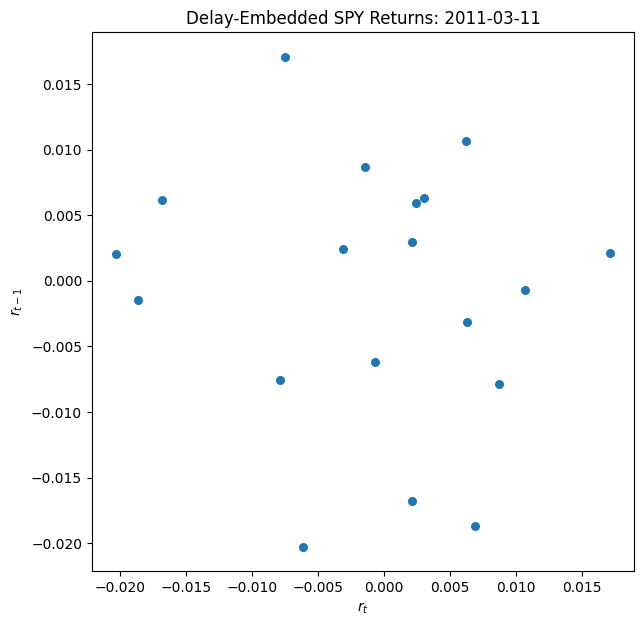

In [31]:
plt.figure(figsize=(7, 7))

plt.scatter(
    selected_embedding[:, 0],
    selected_embedding[:, 1],
    s=30
)

plt.xlabel(r"$r_t$")
plt.ylabel(r"$r_{t-1}$")
plt.title(
    f"Delay-Embedded SPY Returns: "
    f"{window_dates[h1_window_index].date()}"
)

plt.show()

Plot its persistence diagram:

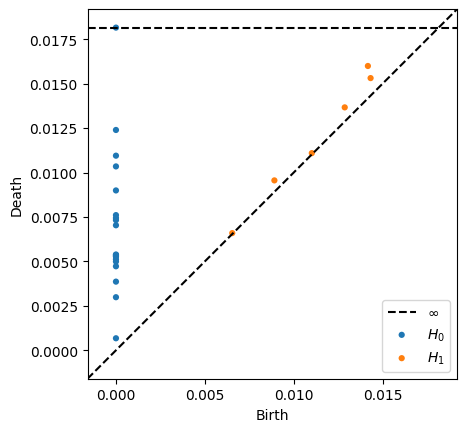

In [32]:
plot_diagrams(
    selected_diagram,
    show=True
)

Persistence landcape:

In [36]:
from persim import PersLandscapeExact
from persim.landscapes import plot_landscape_simple

In [37]:
h1_landscape = PersLandscapeExact(
    dgms=selected_diagram,
    hom_deg=1
)

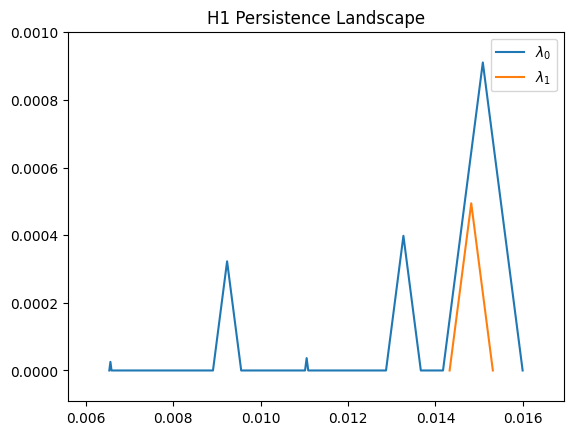

In [39]:
plot_landscape_simple(
    h1_landscape,
    title="H1 Persistence Landscape"
)

plt.show()

**Observation:**

- The blue curve $\lambda_0$ is the first persistence-landscape function, corresponding to the most persistent $H_1$ feature at each filtration scale.
- The orange curve $\lambda_1$ is the second landscape function, corresponding to the second-most persistent feature.
- There are several relatively small peaks in $\lambda_0$, and one noticeably larger peak around $x\approx 0.015$.
- The fact that $\lambda_1$ is nonzero tells us that there are at least two $H_1$ features whose tent functions overlap in scale in this window.
- Importantly, the vertical scale is persistence: the largest feature reaches roughly $9\times10^{-4}$.

This is exactly why the landscape is useful: instead of looking at six \(H_1\) points individually in the persistence diagram, we have converted them into a functional object that can subsequently be summarized quantitatively.

**Next: compute landscape norms**

Since Gidea–Katz use $L^p$ norms of persistence landscapes, let's calculate the $L^1$ and $L^2$ norms for this same example.

In [40]:
l1_norm = h1_landscape.p_norm(p=1)
l2_norm = h1_landscape.p_norm(p=2)
sup_norm = h1_landscape.sup_norm()

print("L1 norm:", l1_norm)
print("L2 norm:", l2_norm)
print("Supremum norm:", sup_norm)

L1 norm: 1.3377202793560879e-06
L2 norm: 2.545809135115984e-05
Supremum norm: 0.0009104735217988491


#### Interpreting the Landscape Norms

The persistence landscape can be summarized by several norms.

The $L^1$ norm measures the total magnitude of the landscape,

$$
\|\lambda\|_1
=
\int |\lambda(x)|\,dx,
$$

while the $L^2$ norm gives greater weight to regions where the landscape
has larger values,

$$
\|\lambda\|_2
=
\left(
\int |\lambda(x)|^2\,dx
\right)^{1/2}.
$$

The supremum norm measures the maximum height of the landscape,

$$
\|\lambda\|_\infty
=
\sup_x |\lambda(x)|.
$$

For the selected window, we obtain

$$
\|\lambda\|_1 \approx 1.34\times10^{-6},
$$

$$
\|\lambda\|_2 \approx 2.55\times10^{-5},
$$

and

$$
\|\lambda\|_\infty \approx 9.21\times10^{-4}.
$$

These quantities provide scalar summaries of the topological structure in
this particular window. Their main purpose in this project, however, is not
to interpret this single value in isolation. Instead, we will compute them
for each sliding window and study how they evolve through time.

### 5.3.1 Landscape Norms Across All Windows

We now compute persistence landscapes for the $H_1$ persistence diagram of
each sliding window.

For each window, we record the $L^1$, $L^2$, and supremum norms of the
persistence landscape. These quantities provide scalar measures of the
topological structure in each local window.

Some windows contain no $H_1$ features. For these windows, the corresponding
persistence landscape is taken to be zero, and all three norms are therefore
set to zero.

This produces time series of topological quantities that can later be compared
with the conventional volatility measures developed in the EDA notebook.

In [41]:
landscape_results = []

for window, date in zip(windows, window_dates):

    # Construct the delay embedding.
    embedding = delay_embedding(
        window,
        tau=TAU,
        dimension=DIMENSION
    )

    # Compute persistent homology.
    diagrams = compute_persistence_diagram(
        embedding,
        max_dimension=1
    )

    # Extract the H1 persistence diagram.
    h1_diagram = diagrams[1]

    # If there are no H1 features, assign zero norms.
    if len(h1_diagram) == 0:
        l1_norm = 0.0
        l2_norm = 0.0
        sup_norm = 0.0

    else:
        # Construct the exact persistence landscape.
        landscape = PersLandscapeExact(
            dgms=diagrams,
            hom_deg=1
        )

        l1_norm = landscape.p_norm(p=1)
        l2_norm = landscape.p_norm(p=2)
        sup_norm = landscape.sup_norm()

    landscape_results.append(
        {
            "date": date,
            "h1_l1_norm": l1_norm,
            "h1_l2_norm": l2_norm,
            "h1_sup_norm": sup_norm,
        }
    )

landscape_results = pd.DataFrame(landscape_results)

landscape_results.head()

,date,h1_l1_norm,h1_l2_norm,h1_sup_norm
0,2010-02-02,0.000000e+00,0.00000,0.00000
1,2010-02-03,7.061733e-07,0.00002,0.00084
2,2010-02-04,7.061733e-07,0.00002,0.00084
3,2010-02-05,7.061733e-07,0.00002,0.00084
4,2010-02-08,7.061733e-07,0.00002,0.00084


verify the result:

In [42]:
print("Shape:", landscape_results.shape)
print("Columns:", landscape_results.columns.tolist())
print()
print(landscape_results.describe())

Shape: (4171, 4)
Columns: ['date', 'h1_l1_norm', 'h1_l2_norm', 'h1_sup_norm']

                             date    h1_l1_norm   h1_l2_norm  h1_sup_norm
count                        4171  4.171000e+03  4171.000000  4171.000000
mean   2018-05-15 10:23:09.594821  1.588439e-06     0.000026     0.000779
min           2010-02-02 00:00:00  0.000000e+00     0.000000     0.000000
25%           2014-03-25 12:00:00  5.635418e-08     0.000003     0.000211
50%           2018-05-15 00:00:00  3.449167e-07     0.000010     0.000527
75%           2022-07-06 12:00:00  1.444465e-06     0.000031     0.001047
max           2026-09-01 00:00:00  2.878878e-04     0.001801     0.016944
std                           NaN  6.864161e-06     0.000056     0.000889


A couple of useful checks from our output:

- `landscape_results.shape == (4171, 4)` — exactly one row per sliding window.
- The first window has no $H_1$ features, so all three norms are correctly zero.
- The second through fifth windows reproduce the same landscape norms, which is consistent with the identical $H_1$ persistence structure we saw earlier.
- The norms have substantial variation over the sample:
   + $L^1$: max $\approx 2.89\times10^{-4}$
   + $L^2$: max $\approx 1.80\times10^{-2}$
   + $L^\infty$: max $\approx 1.69\times10^{-2}$

One thing to fix before moving on: our describe() output treats date as a datetime column, so its mean, min, etc. appear in the table. For the statistical summary it's cleaner to describe only the numerical landscape quantities:

In [43]:
landscape_results[
    ["h1_l1_norm", "h1_l2_norm", "h1_sup_norm"]
].describe()

,h1_l1_norm,h1_l2_norm,h1_sup_norm
count,4.171000e+03,4171.000000,4171.000000
mean,1.588439e-06,0.000026,0.000779
std,6.864161e-06,0.000056,0.000889
min,0.000000e+00,0.000000,0.000000
25%,5.635418e-08,0.000003,0.000211
50%,3.449167e-07,0.000010,0.000527
75%,1.444465e-06,0.000031,0.001047
max,2.878878e-04,0.001801,0.016944


The next step is a single figure showing how the three landscape norms evolve through time. This is where the TDA analysis starts becoming genuinely time-dependent rather than just a collection of local calculations.

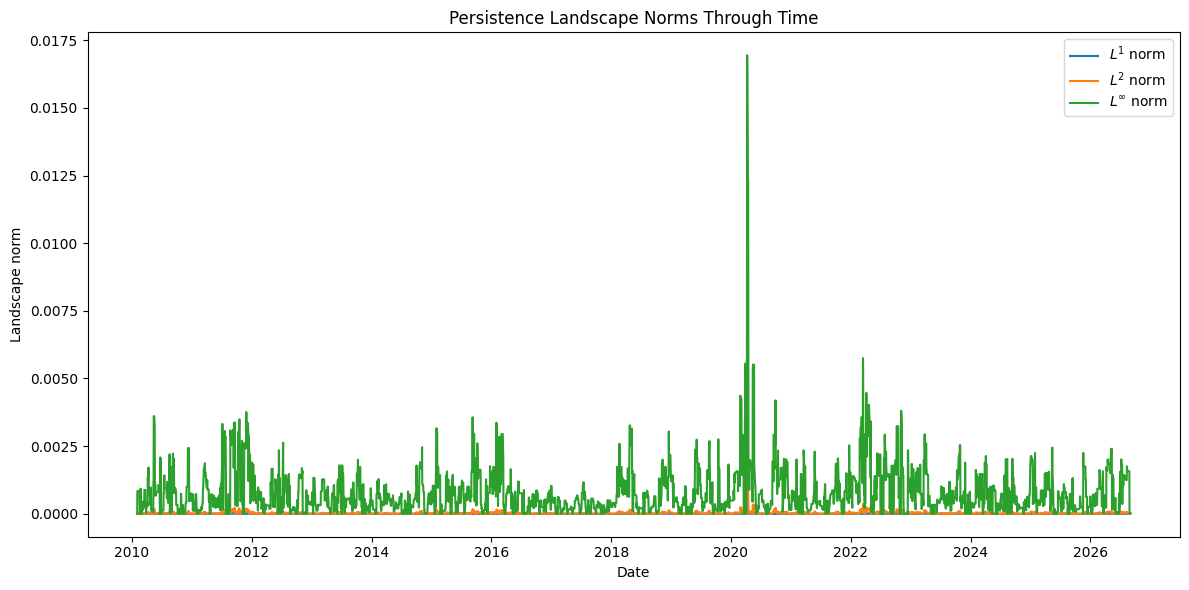

In [44]:
plt.figure(figsize=(12, 6))

plt.plot(
    landscape_results["date"],
    landscape_results["h1_l1_norm"],
    label=r"$L^1$ norm"
)

plt.plot(
    landscape_results["date"],
    landscape_results["h1_l2_norm"],
    label=r"$L^2$ norm"
)

plt.plot(
    landscape_results["date"],
    landscape_results["h1_sup_norm"],
    label=r"$L^\infty$ norm"
)

plt.xlabel("Date")
plt.ylabel("Landscape norm")
plt.title("Persistence Landscape Norms Through Time")
plt.legend()
plt.tight_layout()
plt.show()

**Observation:**

The $L^\infty$ norm dominates the vertical scale. Consequently, the $L^1$ and $L^2$ curves are compressed very close to zero and are difficult to see.

There is also a very pronounced spike in the $L^\infty$ norm around 2020, with smaller clusters of elevated values around periods such as 2011–12, 2015–16, 2018, and 2022.

We should not yet interpret these spikes as evidence that TDA detects market crashes. At this point, all we can say is that the local persistence-landscape structure becomes substantially larger during these periods. The comparison with volatility comes later.

**Let's separate the three norms**

Rather than putting three quantities with very different scales on one axis, make three vertically stacked plots:

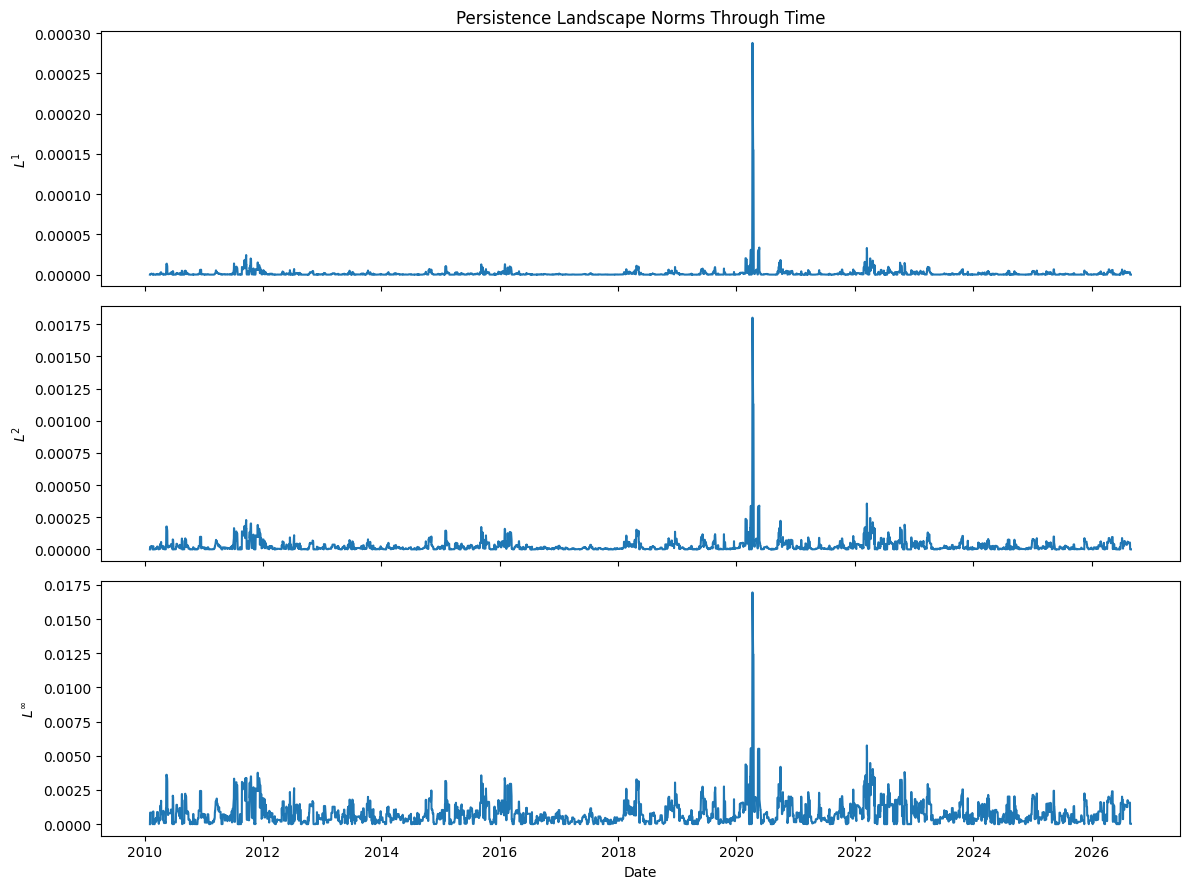

In [45]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 9),
    sharex=True
)

axes[0].plot(
    landscape_results["date"],
    landscape_results["h1_l1_norm"]
)
axes[0].set_ylabel(r"$L^1$")
axes[0].set_title("Persistence Landscape Norms Through Time")

axes[1].plot(
    landscape_results["date"],
    landscape_results["h1_l2_norm"]
)
axes[1].set_ylabel(r"$L^2$")

axes[2].plot(
    landscape_results["date"],
    landscape_results["h1_sup_norm"]
)
axes[2].set_ylabel(r"$L^\infty$")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.show()

**What we see:**

The three quantities show broadly similar temporal structure:

The $L^1$, $L^2$, and $L^\infty$ norms all exhibit a very large spike around the 2020 COVID-period market shock.
There are smaller clusters of elevated topological activity around 2011–12, 2015–16, 2018, and 2022.
The $L^\infty$ series is the most sensitive to individual highly persistent features, while $L^1$ aggregates the landscape more globally.
The three measures are clearly not constant background noise; their magnitude changes substantially over time.

But this is still descriptive. In particular, we should not conclude from this plot alone that the topological quantities predict volatility or crashes. We now have the right setup to test that question.

### 5.4 Topological Quantities Through Time

The persistence-landscape norms provide time-dependent summaries of the local
topological structure of the delay-embedded return series.

We now compare these quantities with conventional measures of volatility.

In particular, we consider the backward-looking 20-day volatility and the
forward-looking five-day realized volatility introduced in the exploratory
data analysis.

The comparison is descriptive at this stage. A visual association between
topological quantities and volatility does not by itself establish predictive
power or causality. Formal predictive evaluation will be carried out later in
the modeling notebooks.

Recreate the two volatility quantities in this notebook so that 04_tda.ipynb remains reproducible independently:

In [46]:
CURRENT_VOL_WINDOW = 20
FUTURE_RV_WINDOW = 5

tda_data = spy_data.copy()

tda_data["current_20d_vol"] = np.sqrt(
    tda_data["log_return"]
    .pow(2)
    .rolling(CURRENT_VOL_WINDOW)
    .mean()
)

future_squared_returns = (
    tda_data["log_return"]
    .pow(2)
    .shift(-1)
)

tda_data["future_5d_rv"] = np.sqrt(
    future_squared_returns
    .rolling(FUTURE_RV_WINDOW)
    .mean()
    .shift(-(FUTURE_RV_WINDOW - 1))
)

now merge tda quantities with them:

In [47]:
comparison = pd.merge(
    landscape_results,
    tda_data[
        [
            "current_20d_vol",
            "future_5d_rv"
        ]
    ],
    left_on="date",
    right_index=True,
    how="left"
)

comparison.head()

,date,h1_l1_norm,h1_l2_norm,h1_sup_norm,current_20d_vol,future_5d_rv
0,2010-02-02,0.000000e+00,0.00000,0.00000,0.010433,0.015624
1,2010-02-03,7.061733e-07,0.00002,0.00084,0.010476,0.015488
2,2010-02-04,7.061733e-07,0.00002,0.00084,0.012605,0.008060
3,2010-02-05,7.061733e-07,0.00002,0.00084,0.012578,0.008016
4,2010-02-08,7.061733e-07,0.00002,0.00084,0.012660,0.010124


then check the correlations:

In [48]:
comparison[
    [
        "h1_l1_norm",
        "h1_l2_norm",
        "h1_sup_norm",
        "current_20d_vol",
        "future_5d_rv"
    ]
].corr()

,h1_l1_norm,h1_l2_norm,h1_sup_norm,current_20d_vol,future_5d_rv
h1_l1_norm,1.000000,0.950714,0.761198,0.342216,0.175731
h1_l2_norm,0.950714,1.000000,0.920196,0.415558,0.240190
h1_sup_norm,0.761198,0.920196,1.000000,0.443882,0.277658
current_20d_vol,0.342216,0.415558,0.443882,1.000000,0.593637
future_5d_rv,0.175731,0.240190,0.277658,0.593637,1.000000


#### 5.4.1: Correlation with volatility

The important entries are:

| Quantity                  | Current 20-day volatility | Future 5-day RV |
| ------------------------- | ------------------------: | --------------: |
| \(H_1\) \(L^1\) norm      |                     0.342 |           0.176 |
| \(H_1\) \(L^2\) norm      |                     0.416 |           0.240 |
| \(H_1\) \(L^\infty\) norm |                     0.444 |           0.278 |

There are two observations worth emphasizing:

First, all three landscape norms are positively associated with current volatility. The association is strongest for the supremum norm:

$$ \operatorname{Corr} \left( \|\lambda\|_\infty, \sigma_{20} \right) \approx 0.444. $$

Second, the correlations with future five-day realized volatility are smaller:

$$ 0.176,\quad 0.240,\quad 0.278. $$

So there is some contemporaneous association between local topological structure and volatility, but the simple correlation with subsequent volatility is considerably weaker.

This is already an interesting result because it prevents us from making the much stronger claim that "large persistence landscapes predict future volatility." We haven't established that.

Let's make a scatter plot of the $L^\infty$ landscape norm against future 5-day realized volatility, since \(L^\infty\) has the strongest correlation with the future target.

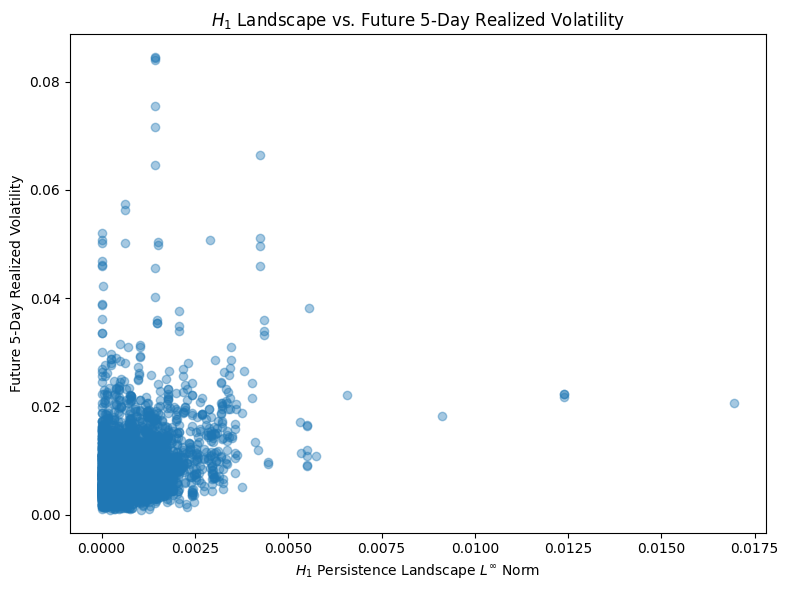

In [49]:
plt.figure(figsize=(8, 6))

plt.scatter(
    comparison["h1_sup_norm"],
    comparison["future_5d_rv"],
    alpha=0.4
)

plt.xlabel(r"$H_1$ Persistence Landscape $L^\infty$ Norm")
plt.ylabel("Future 5-Day Realized Volatility")
plt.title(
    r"$H_1$ Landscape vs. Future 5-Day Realized Volatility"
)

plt.tight_layout()
plt.show()

What the scatter plot shows

There is a broad positive association, consistent with the correlation

$$ \operatorname{Corr} \left( \|\lambda\|_\infty,\mathrm{RV}_{t,t+5} \right) \approx 0.278. $$

But the relationship is clearly not close to linear.

In particular:

- Most observations are concentrated near small $L^\infty$ values.
- Within that region there is a very large range of future volatility.
- There are some observations with substantially larger landscape norms, but they do not correspond to uniformly large future volatility.
- A relatively small number of extreme observations contribute noticeably to the overall correlation.

So the result is better described as:

Larger local $H_1$ landscape magnitude is associated with higher subsequent realized volatility, but the relationship is noisy and highly dispersed.

That's a much more defensible statement than saying that the landscape norm predicts volatility.

**One important comparison:**

Remember that we found

$$ \operatorname{Corr}(L^\infty,\sigma_{20})\approx0.444 $$

but only

$$ \operatorname{Corr}(L^\infty,\mathrm{RV}_{t,t+5})\approx0.278. $$

That suggests that a substantial part of the relationship between topology and future volatility may simply reflect the fact that both are responding to the current volatility state.

This is exactly the kind of issue we should investigate rather than assuming that the TDA quantity provides independent predictive information.

Next: compare with the volatility-ratio quantity

The most relevant quantity for our eventual prediction problem is not simply future volatility. It's the relative change

$$ \log\left( \frac{RV_{t,t+5}} {\sigma_{t,20}} \right). $$

This asks a more interesting question:

Does the local topology contain information about whether future volatility will be substantially higher or lower than the volatility already present?

We already defined this quantity in 03_eda.ipynb. Let's calculate it here and examine its correlation with the three landscape norms.

In [50]:
comparison["log_vol_ratio"] = np.log(
    comparison["future_5d_rv"]
    / comparison["current_20d_vol"]
)

In [51]:
comparison[
    [
        "h1_l1_norm",
        "h1_l2_norm",
        "h1_sup_norm",
        "current_20d_vol",
        "future_5d_rv",
        "log_vol_ratio"
    ]
].corr()

,h1_l1_norm,h1_l2_norm,h1_sup_norm,current_20d_vol,future_5d_rv,log_vol_ratio
h1_l1_norm,1.000000,0.950714,0.761198,0.342216,0.175731,-0.050942
h1_l2_norm,0.950714,1.000000,0.920196,0.415558,0.240190,-0.064901
h1_sup_norm,0.761198,0.920196,1.000000,0.443882,0.277658,-0.080200
current_20d_vol,0.342216,0.415558,0.443882,1.000000,0.593637,-0.199319
future_5d_rv,0.175731,0.240190,0.277658,0.593637,1.000000,0.519431
log_vol_ratio,-0.050942,-0.064901,-0.080200,-0.199319,0.519431,1.000000


**Observation:**

The correlation between the persistence-landscape norms and the
volatility-ratio quantity is considerably weaker than their correlation with
future realized volatility.

For the three landscape norms, the correlations with

$$
\log\left(
\frac{RV_{t,t+5}}{\sigma_{t,20}}
\right)
$$

are approximately

$$
-0.051,\qquad -0.065,\qquad -0.080
$$

for the \(L^1\), \(L^2\), and \(L^\infty\) norms, respectively.

Thus, under the baseline delay-embedding and sliding-window construction,
there is only a weak linear association between the topological quantities
and the relative change in volatility.

This contrasts with the stronger positive association between the landscape
norms and the absolute level of future realized volatility.

These correlations are descriptive and do not establish predictive power.
The question of whether topological features provide useful information for
the volatility-prediction task will be addressed through out-of-sample
modeling later in the project.

Let's look directly at the quantity that matters for the eventual classification problem:

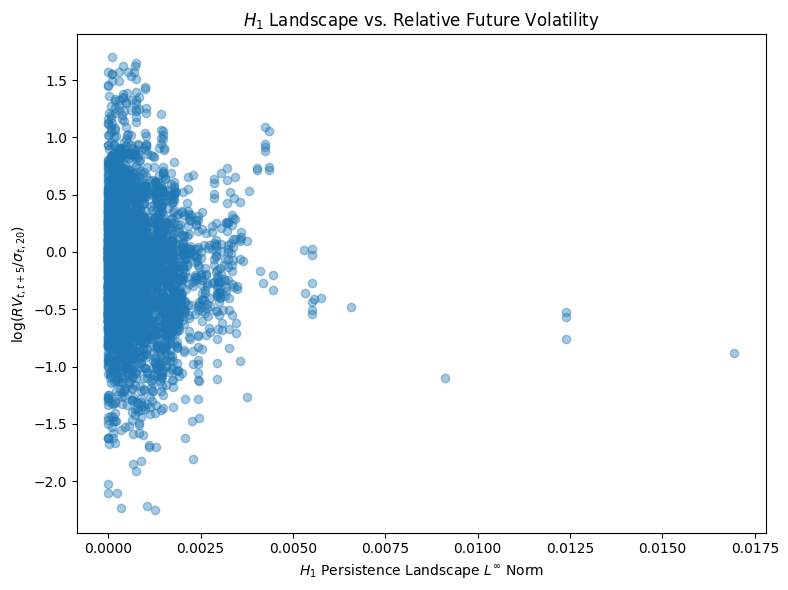

In [52]:
plt.figure(figsize=(8, 6))

plt.scatter(
    comparison["h1_sup_norm"],
    comparison["log_vol_ratio"],
    alpha=0.4
)

plt.xlabel(r"$H_1$ Persistence Landscape $L^\infty$ Norm")
plt.ylabel(r"$\log(RV_{t,t+5}/\sigma_{t,20})$")
plt.title(
    r"$H_1$ Landscape vs. Relative Future Volatility"
)

plt.tight_layout()
plt.show()

**Observation:**

The cloud is extremely diffuse, particularly for small $L^\infty$, and there is no strong linear relationship between the landscape norm and the relative-volatility measure. The few observations with very large $L^\infty$ happen to have negative log-volatility ratios, but they are too sparse to support a strong general relationship.

So I think 5.4 is now complete. The notebook has established a useful distinction:

$$ \boxed{ \text{TDA magnitude} \quad\text{is more strongly associated with absolute volatility} } $$

than with

$$ \boxed{ \text{volatility relative to its recent level}. } $$

That is a meaningful empirical observation, even though it does not establish predictive power.

### 5.5 Comparison with Volatility Regimes

The previous analysis examined correlations between persistence-landscape
quantities and volatility.

We now examine their temporal behavior more directly.

The purpose of this section is descriptive: we compare periods of elevated
volatility with the behavior of the topological quantities. This can reveal
whether large changes in the persistence landscape tend to occur during
particular market regimes.

Such comparisons should not be interpreted as evidence that persistent
homology detects or predicts market crashes. Establishing predictive value
requires an out-of-sample evaluation, which is outside the scope of this
exploratory TDA analysis.

Let's make a two-panel plot. The top panel will show the $H_1 L^\infty$ norm and the bottom panel the conventional 20-day volatility.

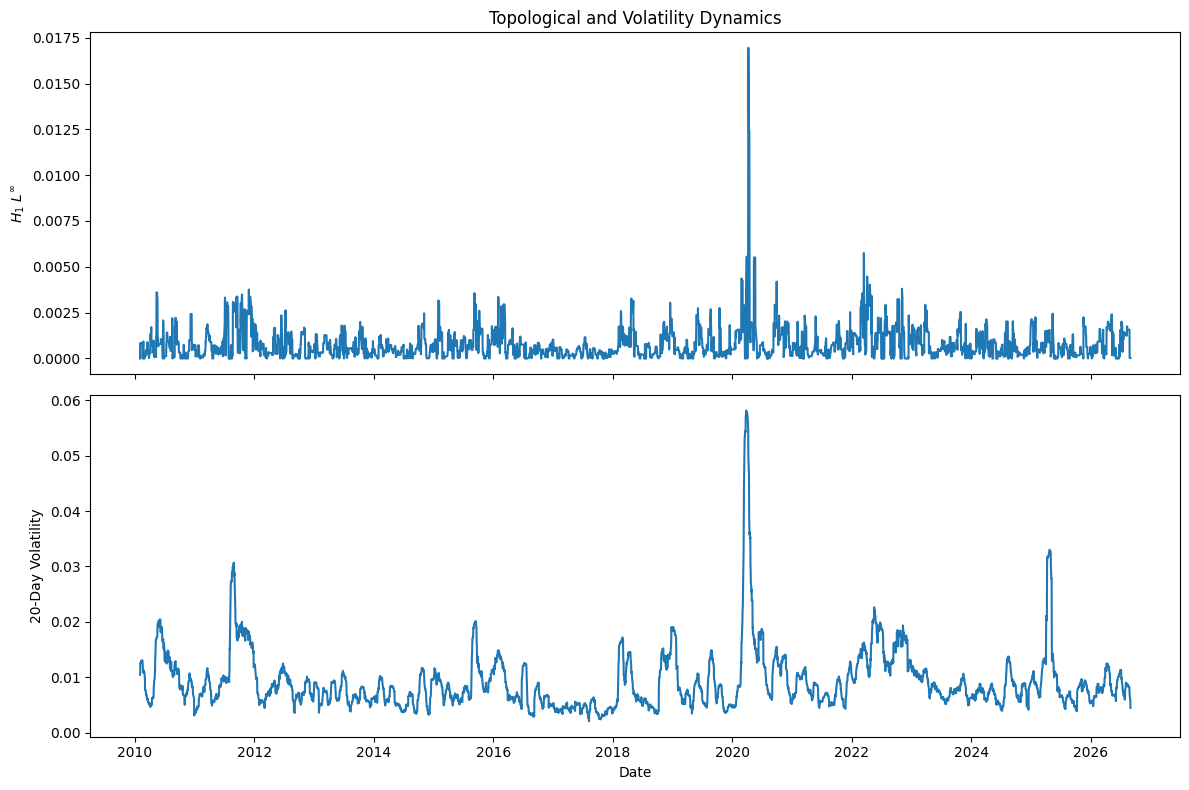

In [55]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    sharex=True
)

axes[0].plot(
    comparison["date"],
    comparison["h1_sup_norm"]
)

axes[0].set_ylabel(r"$H_1$ $L^\infty$")
axes[0].set_title("Topological and Volatility Dynamics")

axes[1].plot(
    comparison["date"],
    comparison["current_20d_vol"]
)

axes[1].set_ylabel("20-Day Volatility")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

**What the two panels show:**

The most striking feature is the 2020 episode: both the $H_1 L^\infty$ norm and 20-day volatility exhibit very large spikes at approximately the same time.

There are also periods where the two series move together more moderately, particularly around:

- 2011–2012
- 2015–2016
- 2018
- 2022

But the correspondence is not one-to-one. There are topological spikes without comparably large volatility spikes, and volatility episodes that do not produce an equally prominent topological spike.

That is actually a useful finding. It suggests that the landscape norm is related to volatility, but is not simply a disguised copy of the volatility series.

**Observation:**

The temporal comparison shows that large values of the $H_1$ persistence
landscape norm can occur during periods of elevated volatility.

The most prominent example in the sample occurs around the 2020 market shock,
where both the $H_1 L^\infty$ norm and 20-day volatility exhibit
substantial spikes.

Elevated topological activity is also visible during several other periods of
increased market volatility. However, the correspondence is not one-to-one:
some topological spikes occur without comparably large volatility spikes, and
some volatility episodes produce relatively modest topological responses.

Thus, the persistence landscape appears to capture information related to
local market dynamics that is correlated with volatility but is not simply
identical to the conventional volatility measure.

This visual comparison remains descriptive. It does not establish that
topological quantities predict volatility or identify market crises.

## 6. Summary

This notebook introduced a time-local Topological Data Analysis of SPY returns.

We constructed sliding windows of daily log returns and transformed each
window into a delay-coordinate point cloud. Persistent homology was then
computed for each point cloud, followed by the construction of $H_1$
persistence landscapes.

The main steps were:

1. Construct sliding windows of SPY returns.
2. Apply a delay-coordinate embedding to each window.
3. Compute persistent homology.
4. Extract persistence statistics.
5. Construct $H_1$ persistence landscapes.
6. Compute $L^1$, $L^2$, and $L^\infty$ landscape norms.
7. Compare these quantities with conventional volatility measures.

The persistence-landscape norms showed a positive association with both current
20-day volatility and future five-day realized volatility. The strongest
association with future volatility was observed for the $L^\infty$ norm, with
a correlation of approximately $0.28$.

However, the association with the relative-volatility quantity

$$
\log\left(
\frac{RV_{t,t+5}}{\sigma_{t,20}}
\right)
$$

was weak, with correlations between approximately $-0.05$ and $-0.08$
for the three landscape norms.

The temporal analysis showed particularly large topological and volatility
responses around the 2020 market shock, while also showing that the two
quantities do not move together perfectly across all periods.

These results motivate the inclusion of topological features in the broader
feature-engineering and modeling pipeline, but they do not by themselves
establish predictive power. That question will be evaluated using
chronological out-of-sample testing in the subsequent modeling notebooks.

## References

[1] M. Gidea and Y. Katz,
"Topological Data Analysis of Financial Time Series: Landscapes of Crashes,"
*Physica A: Statistical Mechanics and its Applications*, vol. 491,
pp. 820--834, 2018.
arXiv:1703.04385.

[2] C. Tralie, N. Saul, and R. Bar-On,
"Ripser.py: A Lean Persistent Homology Library for Python,"
*Journal of Open Source Software*, vol. 4, no. 39, 2019, p. 925.

[3] A. Kumar,
*Topological Data Analysis*,
GitHub repository, 2026.
https://github.com/vaishampayan1729/topological-data-analysis